In [1]:
# /// script
# requires-python = ">=3.10"
# dependencies = [
#     "matplotlib",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
#     "pandas",
# ]
# ///

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import skimage
import tifffile

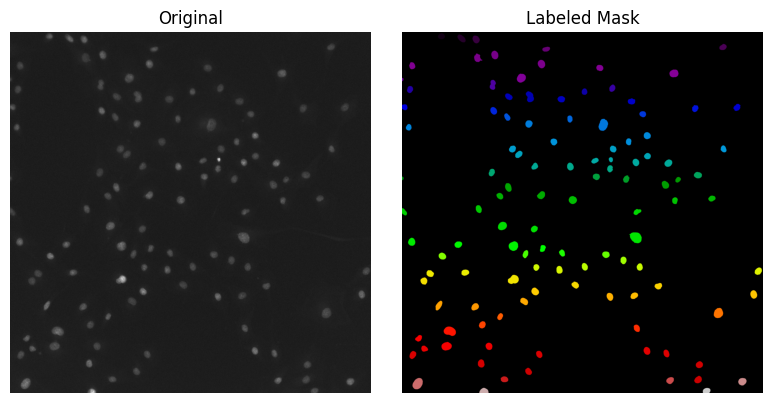

In [3]:
image = tifffile.imread("../../_static/images/quant/DAPI_wf_10.tif")
labeled_mask = tifffile.imread("../../_static/images/quant/DAPI_wf_10_labels.tif")

# Display results
fig, axis = plt.subplots(1, 2, figsize=(8, 4))
axis[0].imshow(image, cmap="gray")
axis[0].set_title("Original")
axis[0].axis("off")
axis[1].imshow(labeled_mask, cmap="nipy_spectral")
axis[1].set_title("Labeled Mask")
axis[1].axis("off")

plt.tight_layout()
plt.show()

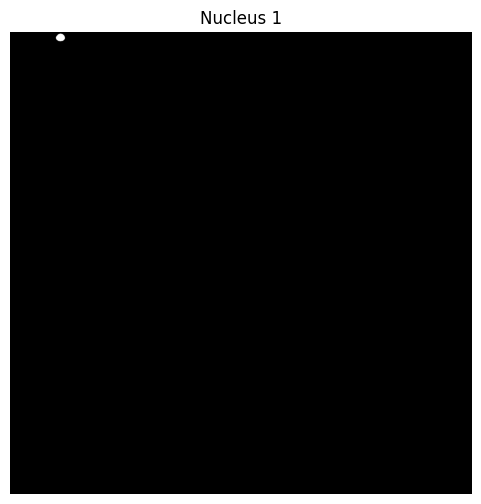

In [4]:
# create an image that contains only the pixels of the first nucleus in the labeled image
nucleus_1 = labeled_mask == 1

# Plot the extracted nucleus image
plt.figure(figsize=(6, 6))
plt.imshow(nucleus_1, cmap="gray")
plt.title("Nucleus 1")
plt.axis("off")
plt.show()

In [5]:
print(np.min(nucleus_1))
print(np.max(nucleus_1))

False
True


In [6]:
# Extract the intensity values of the pixels that belong to this nucleus from the original image
nucleus_1_intensity = image[nucleus_1]
# Print the intensity values
print(nucleus_1_intensity)

[0.14724375 0.16933577 0.20225072 ... 0.14086601 0.09265734 0.16034997]


In [7]:
nucleus_1_mean_intensity = np.mean(nucleus_1_intensity)
print(f"Mean intensity of nucleus 1: {nucleus_1_mean_intensity}")

Mean intensity of nucleus 1: 0.2542710304260254


In [8]:
nucleus_1_area = np.sum(nucleus_1)
print(f"Area of nucleus 1: {nucleus_1_area}")

Area of nucleus 1: 1312


In [9]:
pixel_size = 0.325  # µm
nucleus_1_area_um2 = nucleus_1_area * (pixel_size**2)
print(f"Area of nucleus 1: {nucleus_1_area_um2} um^2")

Area of nucleus 1: 138.58 um^2


In [10]:
props = skimage.measure.regionprops(labeled_mask, image)

In [11]:
props[0]

<RegionProperties: label=1, bbox=(8, 229, 46, 274)>

In [12]:
props[0].mean_intensity

/tmp/ipykernel_3450/2318543170.py:1: FutureWarning: `RegionProperties.mean_intensity` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.intensity_mean` instead. 
  props[0].mean_intensity


np.float32(0.25427103)

/tmp/ipykernel_3450/1647744942.py:4: FutureWarning: `RegionProperties.mean_intensity` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.intensity_mean` instead. 
  mean_intensities.append(prop.mean_intensity)


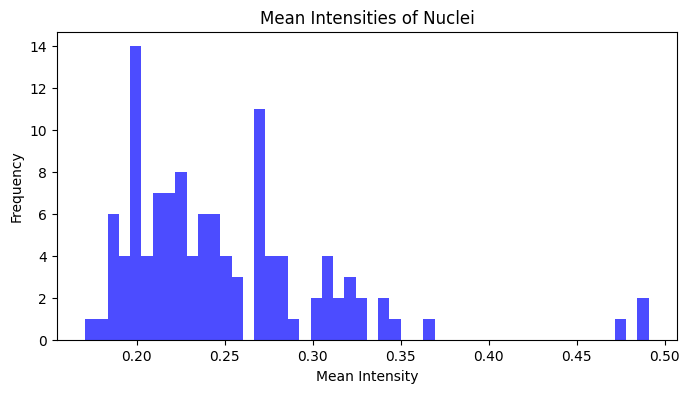

In [13]:
# Extract mean intensity of all regions
mean_intensities = []
for prop in props:
    mean_intensities.append(prop.mean_intensity)
# NOTE: this for loop can also be written as a list comprehension:
# mean_intensities = [prop.mean_intensity for prop in props]

# plot the mean intensities in a histogram
plt.figure(figsize=(8, 4))
plt.hist(mean_intensities, bins=50, color="blue", alpha=0.7)
plt.title("Mean Intensities of Nuclei")
plt.xlabel("Mean Intensity")
plt.ylabel("Frequency")
plt.show()

In [14]:
np.sum(props[0].image_intensity)

np.float32(333.60358)

In [ ]:
raw_image_path = Path("/Users/raw_images_folder")
labels_image_path = Path("/Users/labels_images_folder")

labels_image_suffix = "_labeled.tif"  # How does the labeled image file name end?

# Create a list to store the integrated density values for all nuclei in the dataset
integrated_density_list = []

for raw_image_file in raw_image_path.glob("*.tif"):
    # Load the raw image
    raw_image = tifffile.imread(raw_image_file)
    # Get image name without extension
    image_name = raw_image_file.stem
    # Load the corresponding labeled image
    labels_image_file = labels_image_path / f"{image_name}_{labels_image_suffix}"
    if not labels_image_file.exists():
        print(f"Labels file for {image_name} not found. Skipping...")
        continue
    labeled_mask = tifffile.imread(labels_image_file)
    # Get region properties
    props = skimage.measure.regionprops(labeled_mask, intensity_image=raw_image)
    # Calculate total integrated density for each nucleus
    for prop in props:
        integrated_density = np.sum(prop.image_intensity)
        integrated_density_list.append(integrated_density)
    # same as:
    # integrated_density_list.extend([np.sum(prop.image_intensity) for prop in props])

# Plot the distribution of integrated density values
plt.figure(figsize=(8, 4))
plt.hist(integrated_density_list, bins=250, color="blue", alpha=0.7)
plt.title("Integrated Density Distribution of Nuclei")
plt.xlabel("Integrated Density")
plt.ylabel("Frequency")
plt.show()

In [15]:
# raw image and labeled mask
image = tifffile.imread("../../_static/images/quant/DAPI_wf_10.tif")
labeled_mask = tifffile.imread("../../_static/images/quant/DAPI_wf_10_labels.tif")

In [16]:
props_dict = skimage.measure.regionprops_table(
    labeled_mask, intensity_image=image, properties=["label", "image_intensity", "area"]
)
print(props_dict.keys())

dict_keys(['label', 'image_intensity', 'area'])


In [17]:
integrated_density_list = props_dict["image_intensity"]
# let's print the first three values since the list can be long
print(integrated_density_list[:3])

[array([[-0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(38, 45), dtype=float32)
 array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0., -0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(51, 52), dtype=float32)
 array([[ 0.,  0.,  0., ...,  0.,  0., -0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0., -0.,  0.]], shape=(50, 46), dtype=float32)]


In [18]:
props_df = pd.DataFrame(props_dict)
print(props_df)

     label                                    image_intensity    area
0        1  [[-0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0, 0.0, 0....  1312.0
1        2  [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...  1748.0
2        3  [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...  1729.0
3        4  [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...  1351.0
4        5  [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...  1185.0
..     ...                                                ...     ...
110    111  [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...  1622.0
111    112  [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...  3556.0
112    113  [[0.0, 0.0, 0.0, -0.0, 0.0, 0.0, 0.0, 0.0, 0.0...  1971.0
113    114  [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...  1488.0
114    115  [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...  1339.0

[115 rows x 3 columns]


In [19]:
image_intensity = props_df["image_intensity"]
print(image_intensity)

0      [[-0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0, 0.0, 0....
1      [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
2      [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
3      [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
4      [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
                             ...                        
110    [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
111    [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
112    [[0.0, 0.0, 0.0, -0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
113    [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
114    [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
Name: image_intensity, Length: 115, dtype: object


In [20]:
integrated_density_0 = np.sum(image_intensity[0])
print(integrated_density_0)

333.60358


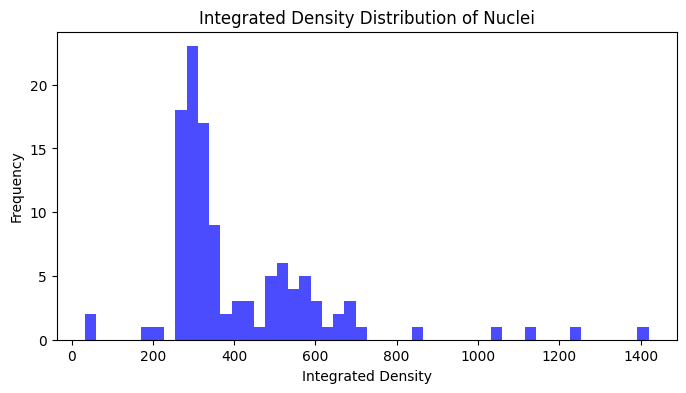

In [21]:
# Calculate integrated density for each nucleus
integrated_densities = []
for intensity_array in props_df["image_intensity"]:
    integrated_density = np.sum(intensity_array)
    integrated_densities.append(integrated_density)
# same as:
# integrated_densities = [np.sum(intensity_array) for intensity_array in props_df['image_intensity']]

# Plot histogram of integrated densities
plt.figure(figsize=(8, 4))
plt.hist(integrated_densities, bins=50, color="blue", alpha=0.7)
plt.title("Integrated Density Distribution of Nuclei")
plt.xlabel("Integrated Density")
plt.ylabel("Frequency")
plt.show()

In [22]:
# Add integrated density as a new column
props_df["integrated_density"] = integrated_densities

# Print the first few rows of the DataFrame to verify the new column
props_df.head()

,label,image_intensity,area,integrated_density
0,1,"[[-0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0, 0.0, 0....",1312.0,333.603577
1,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1748.0,479.227600
2,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1729.0,493.648102
3,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1351.0,278.010895
4,5,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1185.0,283.689819


In [23]:
mean_area = props_df["area"].mean()
mean_density = props_df["integrated_density"].mean()

# conditional filtering
large_bright_nuclei = props_df.loc[
    (props_df["area"] > mean_area) & (props_df["integrated_density"] > mean_density)
]

print(
    f"% of nuclei larger than average and brighter than average: {len(large_bright_nuclei) / len(props_df) * 100}%"
)

% of nuclei larger than average and brighter than average: 27.82608695652174%


In [24]:
selected_labels = large_bright_nuclei["label"].values
selected_mask = np.isin(labeled_mask, selected_labels)

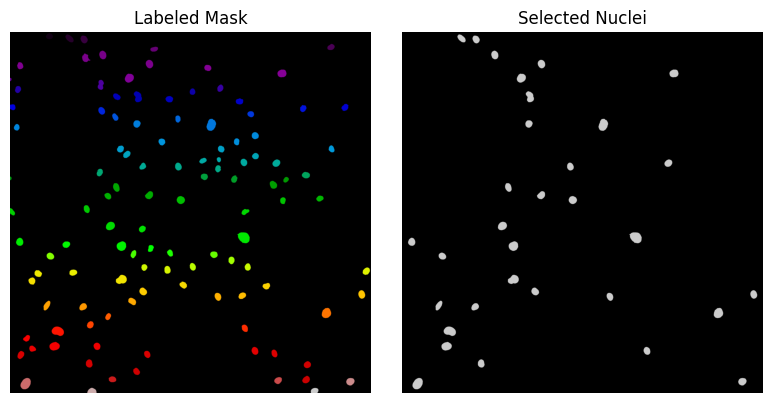

In [25]:
fig, axis = plt.subplots(1, 2, figsize=(8, 4))
axis[0].imshow(labeled_mask, cmap="nipy_spectral")
axis[0].set_title("Labeled Mask")
axis[0].axis("off")
axis[1].imshow(selected_mask, cmap="nipy_spectral")
axis[1].set_title("Selected Nuclei")
axis[1].axis("off")
plt.tight_layout()
plt.show()

In [26]:
props_df.iloc[:10].head()

,label,image_intensity,area,integrated_density
0,1,"[[-0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0, 0.0, 0....",1312.0,333.603577
1,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1748.0,479.227600
2,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1729.0,493.648102
3,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1351.0,278.010895
4,5,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1185.0,283.689819


In [27]:
props_df.iloc[:10, :3].head()

,label,image_intensity,area
0,1,"[[-0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0, 0.0, 0....",1312.0
1,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1748.0
2,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1729.0
3,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1351.0
4,5,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1185.0


In [ ]:
props_df.to_csv("nucleus_measurements.csv", index=False)

In [ ]:
props_df_loaded = pd.read_csv("nucleus_measurements.csv")
# check the data
props_df_loaded.head()